In [2]:
# Cell 1 — Imports & basic config
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import joblib
from tqdm import tqdm
import os
tqdm.pandas()


In [21]:
# Cell 2 — Load data (adjust paths)
DATA_PATH = os.path.join(".", "68e8d1d70b66d_student_resource", "student_resource", "dataset")
train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"), dtype={'sample_id': str})
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"), dtype={'sample_id': str})

# ensure catalog_content is string
train['catalog_content'] = train['catalog_content'].fillna('').astype(str)
test['catalog_content']  = test['catalog_content'].fillna('').astype(str)

print("Train rows:", len(train), "Test rows:", len(test))
train.head(2)


Train rows: 75000 Test rows: 75000


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12


In [22]:
# Cell 3 — Enhanced text cleaning function
import re

def clean_text(s):
    s = str(s)
    
    # Normalize newlines/spaces
    s = re.sub(r'\r\n', '\n', s)
    s = re.sub(r'\u2019', "'", s)  # smart quote -> normal
    s = re.sub(r'\u2018', "'", s)  # another smart quote
    s = re.sub(r'\u201c|\u201d', '"', s)  # smart double quotes
    
    # Remove extra whitespace but keep structure
    s = re.sub(r'\s+', ' ', s).strip()
    
    # Convert to lowercase for consistency (optional - test both ways)
    # s = s.lower()  # Uncomment if you want lowercase
    
    return s

train['catalog_content_clean'] = train['catalog_content'].progress_apply(clean_text)
test['catalog_content_clean']  = test['catalog_content'].progress_apply(clean_text)

print("Example cleaned text:", train['catalog_content_clean'].iloc[1][:500])
print(f"\nTrain shape: {train.shape}")
print(f"Test shape: {test.shape}")

100%|██████████| 75000/75000 [00:02<00:00, 25014.56it/s]

Example cleaned text: Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4) Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925 Value: 32.0 U

Train shape: (75000, 5)
Test shape: (75000, 4)


In [23]:
# Cell 4 — Catalog parsing (minimal changes only)

field_patterns = {
    'item_name': r'Item Name:\s*(.*?)(?:Bullet Point|Product Description:|Value:|Unit:|$)',
    'product_description': r'Product Description:\s*(.*?)(?:Value:|Unit:|$)',
    'value': r'Value:\s*([\d\.]+)',
    'unit': r'Unit:\s*([A-Za-z0-9\.\s%/()-]+)'
}

bullet_pattern = r'Bullet Point\s*\d+:\s*(.*?)(?=Bullet Point\s*\d+:|Product Description:|Value:|Unit:|$)'

# Catalog parser
def parse_catalog(text):
    t = text or ""
    out = {}
    
    # Item Name
    m = re.search(field_patterns['item_name'], t, flags=re.IGNORECASE | re.DOTALL)
    out['item_name'] = (m.group(1).strip() if m and m.group(1) else '').strip()

    # Bullet Points
    bullets = re.findall(bullet_pattern, t, flags=re.IGNORECASE | re.DOTALL)
    out['bullets'] = [b.strip() for b in bullets if b.strip()]

    # Product Description
    m = re.search(field_patterns['product_description'], t, flags=re.IGNORECASE | re.DOTALL)
    out['product_description'] = (m.group(1).strip() if m and m.group(1) else '').strip()

    # Value (numeric)
    m = re.search(field_patterns['value'], t, flags=re.IGNORECASE)
    out['value'] = float(m.group(1)) if m else np.nan

    # Unit
    m = re.search(field_patterns['unit'], t, flags=re.IGNORECASE)
    out['unit'] = (m.group(1).strip() if m and m.group(1) else '').strip()

    return out

# Apply parsing
print("Parsing train data...")
train_parsed = train['catalog_content_clean'].progress_apply(parse_catalog).apply(pd.Series)

print("Parsing test data...")
test_parsed = test['catalog_content_clean'].progress_apply(parse_catalog).apply(pd.Series)

# Drop existing parsed columns before merging
parsed_cols = ['item_name', 'bullets', 'product_description', 'value', 'unit']
train = train.drop(columns=[col for col in parsed_cols if col in train.columns])
test = test.drop(columns=[col for col in parsed_cols if col in test.columns])

# Merge parsed columns
train = pd.concat([train, train_parsed], axis=1)
test = pd.concat([test, test_parsed], axis=1)

# Printing examples
print("\nExample item name:", train['item_name'].iloc[0])
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Parsing train data...


100%|██████████| 75000/75000 [00:05<00:00, 13557.17it/s]


Parsing test data...


100%|██████████| 75000/75000 [00:06<00:00, 12417.58it/s]



Example item name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Train shape: (75000, 10)
Test shape: (75000, 9)


In [53]:
# Cell 5 — Enhanced brand extraction and pack quantity extraction

def extract_brand(item_name):
    """Extract brand name from item name"""
    if not item_name: 
        return 'unknown'
    
    # If there's a colon, brand is usually before it
    if ':' in item_name:
        brand = item_name.split(':')[0].strip()
        if brand:
            return brand
    
    # Try to get first 1-2 capitalized words as brand
    m = re.match(r'^([A-Z][A-Za-z0-9&\-\']+(?:\s+[A-Z][A-Za-z0-9&\-\']+)?)', item_name)
    if m:
        return m.group(1)
    
    # Fallback: first token
    token = item_name.split()[0] if item_name.split() else 'unknown'
    return token

def extract_pack_quantity(text):
    """Extract pack quantity from text"""
    t = str(text).lower()
    
    # Patterns: "pack of 6", "pack of 4", "(Pack of 6)", etc.
    patterns = [
        r'pack of\s*(\d+)',
        r'\(pack of\s*(\d+)\)',
        r'(\d+)\s*[-]*\s*pack\b',
        r'(\d+)\s*(pcs|pieces|count|ct)\b',
        r'(\d+)\s*[-]\s*(pack|count|ct)\b'
    ]
    
    for pattern in patterns:
        m = re.search(pattern, t)
        if m:
            return int(m.group(1))
    
    # Fallback: 1 if no explicit multiplicity
    return 1

# Apply both
print("Extracting brand names...")
train['brand_raw'] = train['item_name'].progress_apply(extract_brand)
test['brand_raw'] = test['item_name'].progress_apply(extract_brand)

print("Extracting pack quantities...")
train['pack_quantity'] = train['catalog_content_clean'].progress_apply(extract_pack_quantity)
test['pack_quantity'] = test['catalog_content_clean'].progress_apply(extract_pack_quantity)

# Print statistics
print("\n" + "="*60)
print("EXTRACTION RESULTS")
print("="*60)
print(f"Unique brands: {train['brand_raw'].nunique()}")
print(f"Unknown brands: {(train['brand_raw'] == 'unknown').sum()}")
print(f"\nPack quantity distribution:")
print(train['pack_quantity'].value_counts().head(10))
print(f"\nAverage pack quantity: {train['pack_quantity'].mean():.2f}")
#print the price sample id 59900 product name and descriptionp
print("\nSample ID 59900 details:")
sample_59900 = train[train['sample_id'] == '21269']
if not sample_59900.empty: 
    print(sample_59900[['item_name', 'product_description', 'pack_quantity','price']].to_string(index=False))
print("="*60 + "\n")

Extracting brand names...


  0%|          | 0/75000 [00:00<?, ?it/s]

100%|██████████| 75000/75000 [00:00<00:00, 613825.74it/s]


Extracting pack quantities...


100%|██████████| 75000/75000 [00:02<00:00, 34215.10it/s]


EXTRACTION RESULTS
Unique brands: 30283
Unknown brands: 8

Pack quantity distribution:
pack_quantity
1     43794
6      5465
12     5249
2      4477
3      3869
4      2356
24     1515
8      1241
10      860
5       553
Name: count, dtype: int64

Average pack quantity: 11380306.23

Sample ID 59900 details:
                                                                                                                                                                               item_name product_description  pack_quantity  price
Black Rifle Coffee Company Gunship Roast (Light Roast) Whole Bean Coffee, 12 Ounce Bag of Coffee Beans, Light Roast Coffee Beans, Light Caramel Tasting Notes and an Ultra Smooth Finish                                  1  19.19



In [25]:
# Cell 6 — Enhanced handcrafted features from text

premium_keywords = ['premium','luxury','organic','pro','deluxe','gourmet','authentic','limited','elite','classic']

def make_text_features(df):
    df = df.copy()
    
    # ===== Basic text length features =====
    df['item_name_len_chars'] = df['item_name'].fillna('').apply(len)
    df['item_name_len_words'] = df['item_name'].fillna('').apply(lambda x: len(str(x).split()))
    
    # ===== Bullet point features =====
    df['bullet_count'] = df['bullets'].apply(lambda b: len(b) if isinstance(b, list) else 0)
    df['bullets_len_chars'] = df['bullets'].apply(lambda b: sum(len(x) for x in b) if isinstance(b, list) else 0)
    df['avg_bullet_length'] = df.apply(
        lambda row: row['bullets_len_chars'] / row['bullet_count'] if row['bullet_count'] > 0 else 0, 
        axis=1
    )
    
    # ===== Description features =====
    df['desc_len_chars'] = df['product_description'].fillna('').apply(len)
    df['desc_word_count'] = df['product_description'].fillna('').apply(lambda x: len(str(x).split()))
    
    # ===== Total text length =====
    df['total_text_length'] = df['item_name_len_chars'] + df['bullets_len_chars'] + df['desc_len_chars']
    
    # ===== Numeric token features =====
    df['num_token_count'] = df['catalog_content_clean'].apply(lambda s: len(re.findall(r'\d+(\.\d+)?', str(s))))
    
    # Extract all numbers and compute statistics
    def extract_number_stats(text):
        numbers = re.findall(r'\d+\.?\d*', str(text))
        numbers = [float(n) for n in numbers if float(n) > 0]
        if numbers:
            return {
                'max_number': max(numbers),
                'min_number': min(numbers),
                'mean_number': np.mean(numbers),
                'sum_numbers': sum(numbers)
            }
        return {'max_number': 0, 'min_number': 0, 'mean_number': 0, 'sum_numbers': 0}
    
    num_stats = df['catalog_content_clean'].apply(extract_number_stats).apply(pd.Series)
    df = pd.concat([df, num_stats], axis=1)
    
    # ===== Premium indicators =====
    df['has_premium_word'] = df['catalog_content_clean'].apply(
        lambda s: int(any(pk in str(s).lower() for pk in premium_keywords))
    )
    df['premium_word_count'] = df['catalog_content_clean'].apply(
        lambda s: sum(1 for pk in premium_keywords if pk in str(s).lower())
    )
    
    # ===== Value and unit features =====
    df['value_num'] = df['value'].fillna(0)  # Use 0 instead of NaN for tree models
    df['unit'] = df['unit'].fillna('').apply(lambda x: str(x).strip())
    
    # ===== Weight/size detection =====
    df['has_weight_unit'] = df['catalog_content_clean'].str.contains(
        r'(oz|ounce|ml|l|kg|g|fl oz|oz\.|pound|lb)', 
        case=False, regex=True, na=False
    ).astype(int)
    
    # ===== Total weight calculation (value * pack_quantity) =====
    df['total_weight'] = df['value_num'] * df['pack_quantity']
    
    # ===== Brand features =====
    df['brand'] = df['brand_raw'].fillna('unknown').astype(str).str.lower().str.strip()
    
    # ===== Capital letter ratio (premium products often have better formatting) =====
    df['capital_ratio'] = df['catalog_content_clean'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0
    )
    
    # ===== Special characters (richer descriptions) =====
    df['exclamation_count'] = df['catalog_content_clean'].str.count('!')
    df['comma_count'] = df['catalog_content_clean'].str.count(',')
    
    # ===== Price per unit features =====
    df['value_per_pack'] = df.apply(
        lambda row: row['value_num'] / row['pack_quantity'] if row['pack_quantity'] > 0 else row['value_num'],
        axis=1
    )
    
    return df

print("Creating handcrafted features for train...")
train = make_text_features(train)

print("Creating handcrafted features for test...")
test = make_text_features(test)

print("\n" + "="*60)
print("FEATURE ENGINEERING RESULTS")
print("="*60)
print(f"Total features created: {len([c for c in train.columns if c not in ['sample_id', 'catalog_content', 'catalog_content_clean', 'price']])}")
print(f"\nNew numeric features:")
print(f"  - max_number: {train['max_number'].describe()[['mean', 'max']]}")
print(f"  - total_weight: {train['total_weight'].describe()[['mean', 'max']]}")
print(f"  - premium_word_count: {train['premium_word_count'].value_counts().head()}")

train.head(2)

Creating handcrafted features for train...


C:\Users\nshej\AppData\Local\Temp\ipykernel_29660\2880195503.py:59: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_weight_unit'] = df['catalog_content_clean'].str.contains(


Creating handcrafted features for test...


C:\Users\nshej\AppData\Local\Temp\ipykernel_29660\2880195503.py:59: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['has_weight_unit'] = df['catalog_content_clean'].str.contains(



FEATURE ENGINEERING RESULTS
Total features created: 31

New numeric features:
  - max_number: mean    2.467570e+09
max     2.004530e+13
Name: max_number, dtype: float64
  - total_weight: mean    2.276087e+08
max     1.707044e+13
Name: total_weight, dtype: float64
  - premium_word_count: premium_word_count
1    29830
0    21835
2    16524
3     4808
4     1682
Name: count, dtype: int64


,sample_id,catalog_content,image_link,price,catalog_content_clean,item_name,bullets,product_description,value,unit,...,has_premium_word,premium_word_count,value_num,has_weight_unit,total_weight,brand,capital_ratio,exclamation_count,comma_count,value_per_pack
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"Item Name: La Victoria Green Taco Sauce Mild, ...","La Victoria Green Taco Sauce Mild, 12 Ounce (P...",[],,72.0,Fl Oz,...,0,0,72.0,1,432.0,la victoria,0.155556,0,1,12.0
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"Item Name: Salerno Cookies, The Original Butte...","Salerno Cookies, The Original Butter Cookies, ...",[Original Butter Cookies: Classic butter cooki...,,32.0,Ounce,...,1,1,32.0,1,128.0,salerno cookies,0.076471,0,4,8.0


In [26]:
# Run this to decide:
brand_counts = train['brand'].value_counts()
print(f"Brands appearing 1 time: {(brand_counts == 1).sum()}")
print(f"Brands appearing 2-4 times: {((brand_counts >= 2) & (brand_counts <= 4)).sum()}")
print(f"Brands appearing 5+ times: {(brand_counts >= 5).sum()}")
print(f"\nTotal unique brands: {len(brand_counts)}")

Brands appearing 1 time: 19595
Brands appearing 2-4 times: 6603
Brands appearing 5+ times: 2601

Total unique brands: 28799


In [27]:
# Cell 7 — Encode categorical features (brand, unit) using LabelEncoder fitted on TRAIN only
le_brand = LabelEncoder()
train['brand_enc'] = le_brand.fit_transform(train['brand'].fillna('unknown').astype(str))
# For test, map unseen brands to 'unknown' then transform (handle unseen)
test_brand = test['brand'].fillna('unknown').astype(str)
test_brand_mapped = test_brand.where(test_brand.isin(le_brand.classes_), 'unknown')
# ensure 'unknown' exists in classes; if not, add it
if 'unknown' not in le_brand.classes_:
    le_brand_classes = list(le_brand.classes_) + ['unknown']
    le_brand.classes_ = np.array(le_brand_classes)
test['brand_enc'] = le_brand.transform(test_brand_mapped)

# unit encoding (rare, but do same procedure)
le_unit = LabelEncoder()
train['unit_enc'] = le_unit.fit_transform(train['unit'].fillna(''))
test_unit = test['unit'].fillna('')
test_unit_mapped = test_unit.where(test_unit.isin(le_unit.classes_), '')
# ensure '' exists
if '' not in le_unit.classes_:
    le_unit_classes = list(le_unit.classes_) + ['']
    le_unit.classes_ = np.array(le_unit_classes)
test['unit_enc'] = le_unit.transform(test_unit_mapped)

# Save encoders for later
joblib.dump(le_brand, 'le_brand.joblib')
joblib.dump(le_unit, 'le_unit.joblib')


['le_unit.joblib']

In [44]:
# Cell 8 — TF-IDF vectorization (fit on TRAIN then transform TEST)
# Choose max_features reasonably (e.g., 300 or 1000 depending on memory)


TFIDF_FEATURES = 2000  # Increased from 300 for better coverage

# Optimized TF-IDF parameters
tfidf = TfidfVectorizer(
    max_features=TFIDF_FEATURES,
    ngram_range=(1, 2),           # Unigrams + bigrams
    min_df=3,                     # Ignore very rare terms
    max_df=0.95,                  # Ignore very common terms (almost in all docs)
    sublinear_tf=True,            # Use log scaling for term frequency
    strip_accents='unicode',      # Remove accents
    lowercase=True,               # Convert to lowercase
    stop_words=None               # Keep all words (product names matter!)
)

print("Fitting TF-IDF on train data...")
X_text_tfidf_train = tfidf.fit_transform(train['catalog_content_clean'].fillna(''))

print("Transforming test data...")
X_text_tfidf_test = tfidf.transform(test['catalog_content_clean'].fillna(''))

print("\n" + "="*60)
print("TF-IDF RESULTS")
print("="*60)
print(f"TF-IDF shape (train): {X_text_tfidf_train.shape}")
print(f"TF-IDF shape (test):  {X_text_tfidf_test.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_text_tfidf_train.nnz / (X_text_tfidf_train.shape[0] * X_text_tfidf_train.shape[1])) * 100:.2f}%")

# Show top TF-IDF features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features (first 10): {list(feature_names[:10])}")

# Save vectorizer


print("TF-IDF shape (train):", X_text_tfidf_train.shape)
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')


Fitting TF-IDF on train data...
Transforming test data...

TF-IDF RESULTS
TF-IDF shape (train): (75000, 2000)
TF-IDF shape (test):  (75000, 2000)
Vocabulary size: 2000
Sparsity: 95.84%

Sample features (first 10): ['10', '10 oz', '10 unit', '100', '100 arabica', '100 natural', '100 pure', '11', '12', '12 bullet']
TF-IDF shape (train): (75000, 2000)


['tfidf_vectorizer.joblib']

In [45]:
# Cell 9 — Build comprehensive DataFrame of handcrafted features with correlation analysis

# Updated handcrafted columns (include all new features from Cell 6)
handcrafted_cols = [
    'sample_id',
    # Text length features
    'item_name_len_chars', 'item_name_len_words',
    'bullet_count', 'bullets_len_chars', 'avg_bullet_length',
    'desc_len_chars', 'desc_word_count', 'total_text_length',
    # Numeric features
    'num_token_count', 'max_number', 'min_number', 'mean_number', 'sum_numbers',
    # Premium indicators
    'has_premium_word', 'premium_word_count',
    # Value and weight
    'value_num', 'pack_quantity', 'total_weight', 'value_per_pack',
    'has_weight_unit',
    # Categorical encodings
    'brand_enc', 'unit_enc',
    # Text quality
    'capital_ratio', 'exclamation_count', 'comma_count'
]

# Create dataframes
train_hand = train[handcrafted_cols + ['price']].copy()
test_hand = test[handcrafted_cols].copy()

# Fill NaNs (for safety)
numeric_cols = train_hand.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != 'price' and col != 'sample_id':
        train_hand[col] = train_hand[col].fillna(0)  # Use 0 instead of -1
        test_hand[col] = test_hand[col].fillna(0)

# Convert sample_id to string
train_hand['sample_id'] = train_hand['sample_id'].astype(str)
test_hand['sample_id'] = test_hand['sample_id'].astype(str)

print("="*60)
print("HANDCRAFTED FEATURES SUMMARY")
print("="*60)
print(f"Total handcrafted features: {len(handcrafted_cols) - 1}")  # -1 for sample_id
print(f"Train shape: {train_hand.shape}")
print(f"Test shape: {test_hand.shape}")

# ===== CORRELATION ANALYSIS WITH PRICE =====
print("\n" + "="*60)
print("TOP FEATURES CORRELATED WITH PRICE")
print("="*60)

# Calculate correlations
correlations = train_hand.corr()['price'].drop('price').sort_values(ascending=False)

print("\n🔺 TOP 10 POSITIVE CORRELATIONS (higher value = higher price):")
print(correlations.head(10).to_string())

print("\n🔻 TOP 10 NEGATIVE CORRELATIONS (higher value = lower price):")
print(correlations.tail(10).to_string())

# Check for weak features (abs correlation < 0.05)
weak_features = correlations[abs(correlations) < 0.05]
if len(weak_features) > 0:
    print(f"\n⚠️  Weak features (|correlation| < 0.05): {len(weak_features)}")
    print(weak_features.to_string())

# ===== FEATURE STATISTICS =====
print("\n" + "="*60)
print("KEY FEATURE STATISTICS")
print("="*60)

key_features = ['total_weight', 'pack_quantity', 'value_num', 'max_number', 
                'premium_word_count', 'brand_frequency']

for feat in key_features:
    if feat in train_hand.columns:
        print(f"\n{feat}:")
        print(f"  Mean: {train_hand[feat].mean():.2f}, Median: {train_hand[feat].median():.2f}")
        print(f"  Min: {train_hand[feat].min():.2f}, Max: {train_hand[feat].max():.2f}")
        print(f"  Non-zero: {(train_hand[feat] > 0).sum()} ({(train_hand[feat] > 0).sum()/len(train_hand)*100:.1f}%)")

# ===== MISSING VALUES CHECK =====
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
missing = train_hand.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("✅ No missing values!")

# Display correlation matrix (optional - can comment out)
# print("\nFull correlation matrix:")
# print(train_hand.corr().round(2))

HANDCRAFTED FEATURES SUMMARY
Total handcrafted features: 25
Train shape: (75000, 27)
Test shape: (75000, 26)

TOP FEATURES CORRELATED WITH PRICE

🔺 TOP 10 POSITIVE CORRELATIONS (higher value = higher price):
desc_len_chars         0.179825
desc_word_count        0.179811
total_text_length      0.146795
num_token_count        0.138371
premium_word_count     0.121195
comma_count            0.109682
exclamation_count      0.099634
has_premium_word       0.098569
item_name_len_words    0.093614
item_name_len_chars    0.086787

🔻 TOP 10 NEGATIVE CORRELATIONS (higher value = lower price):
pack_quantity      0.010005
min_number         0.002433
max_number        -0.001110
sum_numbers       -0.001142
mean_number       -0.002361
brand_enc         -0.025223
sample_id         -0.025731
capital_ratio     -0.065209
unit_enc          -0.087757
has_weight_unit         NaN

⚠️  Weak features (|correlation| < 0.05): 10
avg_bullet_length    0.044322
bullet_count         0.017554
total_weight         0.0

<Axes: >

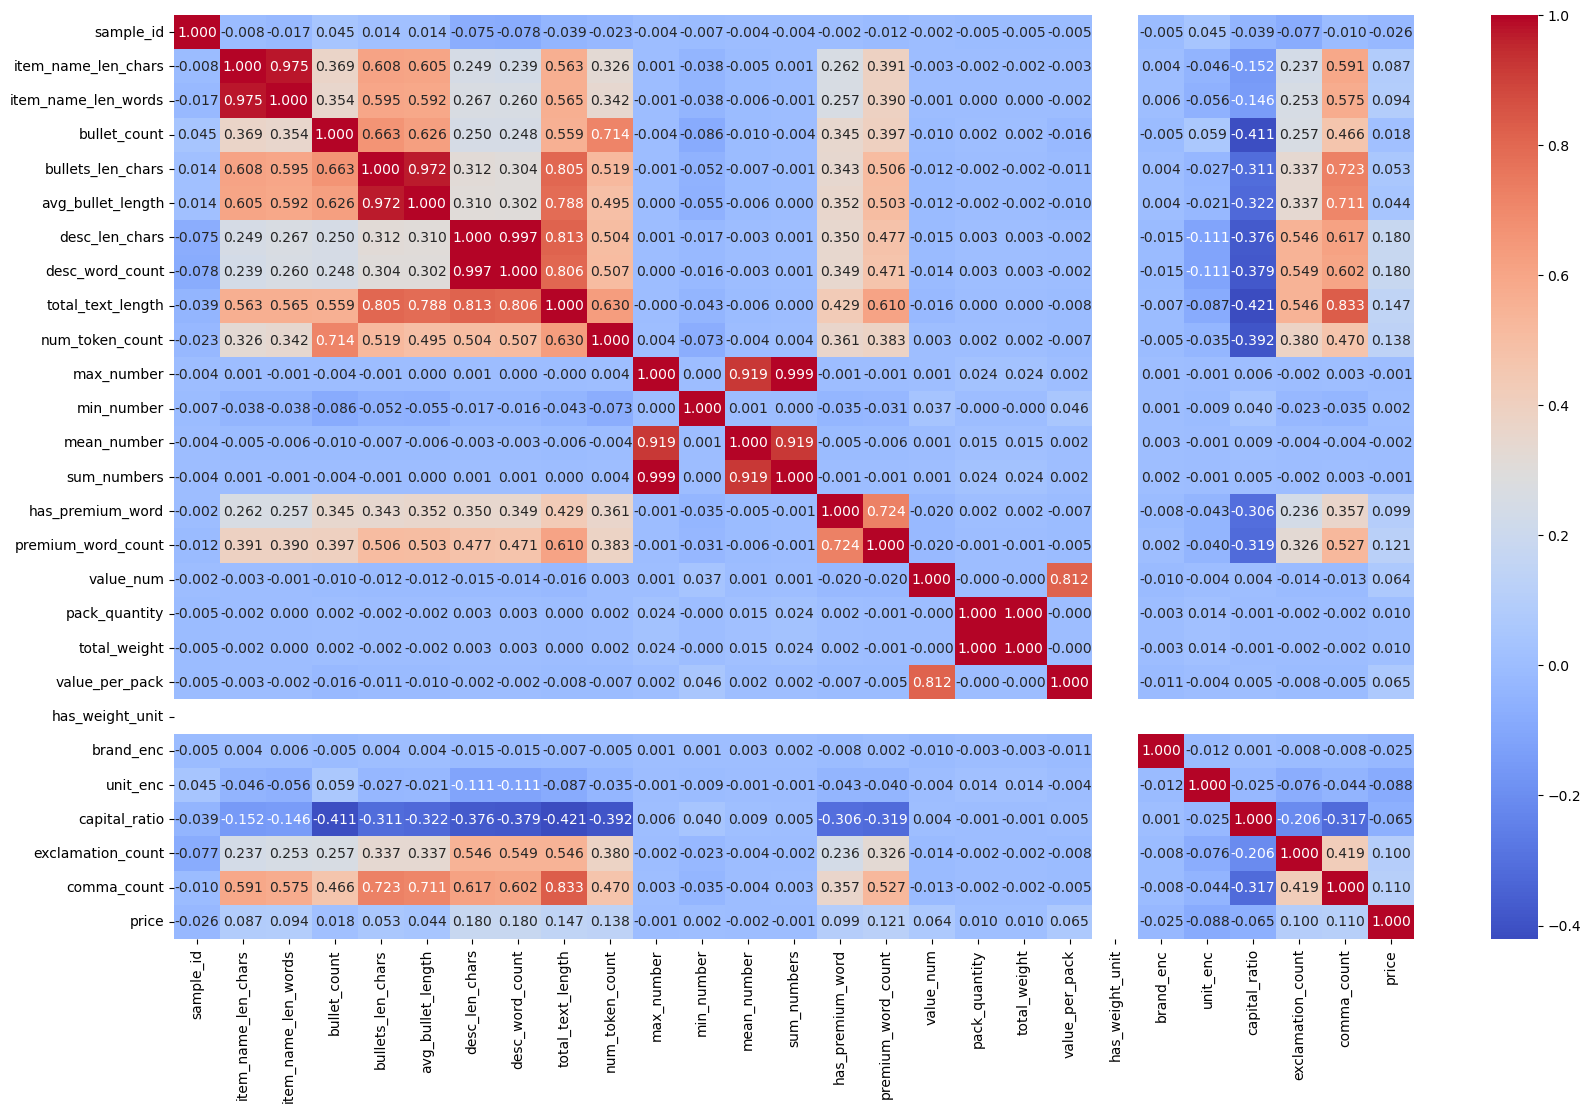

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 12))
sns.heatmap(train_hand.corr(), annot=True, fmt=".3f", cmap="coolwarm")


In [46]:
# Cell 10 — Combine TF-IDF + handcrafted features into final datasets

import scipy.sparse as sp

# Convert sparse -> dense (FIXED: correct train/test assignment)
print("Converting TF-IDF to dense arrays...")
tfidf_train_dense = X_text_tfidf_train.toarray()  # ✅ TRAIN data
tfidf_test_dense = X_text_tfidf_test.toarray()    # ✅ TEST data

print(f"TF-IDF train shape: {tfidf_train_dense.shape}")
print(f"TF-IDF test shape: {tfidf_test_dense.shape}")

# Create TF-IDF DataFrames
tfidf_colnames = [f"tfidf_{i}" for i in range(tfidf_train_dense.shape[1])]
df_tfidf_train = pd.DataFrame(tfidf_train_dense, columns=tfidf_colnames)
df_tfidf_test = pd.DataFrame(tfidf_test_dense, columns=tfidf_colnames)

# Concatenate handcrafted + TF-IDF features
print("\nCombining handcrafted and TF-IDF features...")
train_combined = pd.concat([
    train_hand.reset_index(drop=True), 
    df_tfidf_train.reset_index(drop=True)
], axis=1)

test_combined = pd.concat([
    test_hand.reset_index(drop=True), 
    df_tfidf_test.reset_index(drop=True)
], axis=1)

print("\n" + "="*60)
print("FINAL COMBINED DATASETS")
print("="*60)
print(f"Train combined shape: {train_combined.shape}")
print(f"Test combined shape:  {test_combined.shape}")
print(f"\nFeature breakdown:")
print(f"  - Handcrafted features: {len(train_hand.columns) - 1}")  # -1 for sample_id
print(f"  - TF-IDF features: {len(tfidf_colnames)}")
print(f"  - Total features: {train_combined.shape[1] - 2}")  # -2 for sample_id and price

# Verify no data leakage
print(f"\nData integrity check:")
print(f"  ✅ Train has 'price' column: {'price' in train_combined.columns}")
print(f"  ✅ Test does NOT have 'price' column: {'price' not in test_combined.columns}")
print(f"  ✅ Both have 'sample_id': {'sample_id' in train_combined.columns and 'sample_id' in test_combined.columns}")

# Show sample
print(f"\nTrain sample (first 3 rows, first 10 columns):")
print(train_combined.iloc[:3, :10])

print(f"\nTest sample (first 3 rows, first 10 columns):")
print(test_combined.iloc[:3, :10])

Converting TF-IDF to dense arrays...
TF-IDF train shape: (75000, 2000)
TF-IDF test shape: (75000, 2000)

Combining handcrafted and TF-IDF features...

FINAL COMBINED DATASETS
Train combined shape: (75000, 2027)
Test combined shape:  (75000, 2026)

Feature breakdown:
  - Handcrafted features: 26
  - TF-IDF features: 2000
  - Total features: 2025

Data integrity check:
  ✅ Train has 'price' column: True
  ✅ Test does NOT have 'price' column: True
  ✅ Both have 'sample_id': True

Train sample (first 3 rows, first 10 columns):
  sample_id  item_name_len_chars  item_name_len_words  bullet_count  \
0     33127                   55                   11             0   
1    198967                   65                   11             5   
2    261251                   76                   14             5   

   bullets_len_chars  avg_bullet_length  desc_len_chars  desc_word_count  \
0                  0                0.0               0                0   
1                325              

In [47]:
# Cell 11 — Save processed files
train_combined.to_csv("train_processed_text.csv", index=False)
test_combined.to_csv("test_processed_text.csv", index=False)

# Also save sparse TF-IDF matrices if needed
sp.save_npz("tfidf_train_sparse.npz", X_text_tfidf_train)
sp.save_npz("tfidf_test_sparse.npz", X_text_tfidf_test)

print("Saved: train_processed_text.csv, test_processed_text.csv, tfidf_train_sparse.npz")


Saved: train_processed_text.csv, test_processed_text.csv, tfidf_train_sparse.npz


In [48]:
# Cell 12 — REVISED: Strong regularization to prevent overfitting

from sklearn.model_selection import train_test_split
import lightgbm as lgb
import numpy as np
from joblib import dump
import os
from datetime import datetime

def smape(y_true, y_pred):
    """SMAPE metric for evaluation"""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    smape_vals = np.where(denominator == 0, 0, diff / denominator)
    return np.mean(smape_vals) * 100

os.makedirs('saved_models', exist_ok=True)

# Prepare data
print("Preparing training data...")
X_full = train_combined.drop(['sample_id', 'price'], axis=1).values
y_full = train_combined['price'].values

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")

# HEAVILY REGULARIZED MODEL to prevent overfitting
lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,          # Lower learning rate
    max_depth=10,                # Shallower trees (was 20)
    num_leaves=50,               # Fewer leaves (was 150)
    min_child_samples=50,        # More samples per leaf (was 10)
    min_child_weight=0.01,       # Additional regularization
    subsample=0.7,               # More aggressive row sampling
    subsample_freq=1,            # Apply every iteration
    colsample_bytree=0.7,        # More aggressive column sampling
    reg_alpha=0.15,               # Strong L1 (was 0.3)
    reg_lambda=0.4,              # Strong L2 (was 0.7)
    min_split_gain=0.1,          # Higher threshold to split
    max_bin=200,                 # Reduce bins
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("\n" + "="*60)
print("TRAINING WITH STRONG REGULARIZATION")
print("="*60)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'valid'],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

# Evaluate
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

pred_train = lgb_model.predict(X_train)
pred_val = lgb_model.predict(X_val)

train_smape = smape(y_train, pred_train)
val_smape = smape(y_val, pred_val)
gap = train_smape - val_smape

print(f"Training SMAPE:   {train_smape:.2f}%")
print(f"Validation SMAPE: {val_smape:.2f}%")
print(f"Overfitting Gap:  {gap:.2f}%")

if abs(gap) > 10:
    print("⚠️  Warning: Overfitting gap > 10%. Consider:")
    print("   - Increase regularization further")
    print("   - Reduce model complexity")
    print("   - Add more training data")
elif abs(gap) > 5:
    print("⚠️  Moderate overfitting. Model is acceptable but could improve.")
else:
    print("✅ Overfitting is under control!")

print(f"Best iteration: {lgb_model.best_iteration_}")

# Feature importance
print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)

feature_names = train_combined.drop(['sample_id', 'price'], axis=1).columns
importances = lgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(15).to_string(index=False))

# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_filename = f'saved_models/lgb_regularized_smape_{val_smape:.2f}_run_{timestamp}.joblib'
dump(lgb_model, model_filename)

feature_importance_df.to_csv(f'saved_models/feature_importance_{timestamp}.csv', index=False)

print("\n" + "="*60)
print("MODEL SAVED")
print("="*60)
print(f"✅ {model_filename}")

Preparing training data...
Training set: 60,000 samples
Validation set: 15,000 samples

TRAINING WITH STRONG REGULARIZATION
Training until validation scores don't improve for 150 rounds
[100]	train's l1: 13.0421	train's l2: 601.394	valid's l1: 14.004	valid's l2: 1134.05
[200]	train's l1: 12.3968	train's l2: 543.932	valid's l1: 13.566	valid's l2: 1090.52
[300]	train's l1: 12.0334	train's l2: 510.498	valid's l1: 13.38	valid's l2: 1072.7
[400]	train's l1: 11.7636	train's l2: 485.977	valid's l1: 13.2518	valid's l2: 1060.38
[500]	train's l1: 11.5693	train's l2: 466.911	valid's l1: 13.1837	valid's l2: 1051.32
[600]	train's l1: 11.3883	train's l2: 449.865	valid's l1: 13.134	valid's l2: 1046.01
[700]	train's l1: 11.2442	train's l2: 436.345	valid's l1: 13.0872	valid's l2: 1042.6
[800]	train's l1: 11.1143	train's l2: 423.858	valid's l1: 13.0549	valid's l2: 1039.12
[900]	train's l1: 10.9946	train's l2: 412.614	valid's l1: 13.0211	valid's l2: 1036.81
[1000]	train's l1: 10.8812	train's l2: 402.241	

c:\Users\nshej\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\nshej\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training SMAPE:   51.67%
Validation SMAPE: 59.15%
Overfitting Gap:  -7.48%
⚠️  Moderate overfitting. Model is acceptable but could improve.
Best iteration: 1978

TOP 15 MOST IMPORTANT FEATURES
            feature  importance
     value_per_pack        1941
          value_num        1517
       total_weight        1403
          brand_enc        1218
    num_token_count        1216
        mean_number        1071
        sum_numbers        1001
      capital_ratio         923
         max_number         827
item_name_len_chars         789
         tfidf_1262         648
         tfidf_1202         641
          tfidf_288         622
          tfidf_328         538
         tfidf_1384         516

MODEL SAVED
✅ saved_models/lgb_regularized_smape_59.15_run_20251012_184454.joblib


In [42]:
#using last save best model having smape 58.23 to predict test data
best_model = joblib.load('C:/Users/nshej/Amazon ML/saved_models/lgb_smape_57.39_run_20251012_154856.joblib')  # Adjust filename as needed
X_test_final = test_combined.drop(['sample_id'], axis=1).values
test_preds = best_model.predict(X_test_final)
# Prepare submission
submission = pd.DataFrame({
    'sample_id': test_combined['sample_id'],
    'price': test_preds
})
submission.to_csv('submission.csv', index=False)


c:\Users\nshej\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
